# LAB 2:  
# BÀI THỰC HÀNH TRÌNH BÀY DỮ LIỆU
Nội dung: Trực quan hóa dữ liệu điểm thi đã được xử lý processed_dulieuxettuyendaihoc.csv
Mục tiêu: Sinh viên đạt được kiến thức sau.
• Trình bày dữ liệu cơ bản
• Trực quan hóa dữ liệu cơ bản

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('processed_dulieuxettuyendaihoc.csv')

print(df.head())

   STT   T1   L1   H1   S1   V1   X1   D1   N1   T2  ...  TBM1  TBM2  TBM3  \
0    1  7.2  7.3  6.3  7.3  7.0  7.9  7.3  5.5  8.4  ...  7.00  7.54  7.01   
1    2  5.4  3.9  3.9  4.0  5.4  5.4  5.3  2.8  6.3  ...  4.69  5.47  5.07   
2    3  5.6  6.8  7.2  7.5  4.3  7.4  5.8  3.2  5.0  ...  5.77  5.38  6.04   
3    4  6.6  6.4  5.3  6.9  5.4  7.3  6.4  5.8  5.1  ...  6.21  5.20  6.88   
4    5  6.0  5.0  6.0  7.3  6.5  7.7  7.9  6.1  5.4  ...  6.50  6.36  6.99   

   XL1  XL2  XL3  US_TBM1  US_TBM2  US_TBM3  KQXT  
0    K    K    K    2.800    3.016    2.804   0.0  
1    Y   TB   TB    1.876    2.188    2.028   0.0  
2   TB   TB   TB    2.308    2.152    2.416   1.0  
3   TB   TB    K    2.484    2.080    2.752   0.0  
4    K   TB    K    2.600    2.544    2.796   0.0  

[5 rows x 66 columns]


# Phần 1: Thống kê dữ liệu

1. Hãy sắp xếp dữ liệu điểm DH1 theo thứ tự tăng dần

In [17]:
dh1_sorted = df.sort_values(by='DH1')

print(dh1_sorted[['DH1']])

     DH1
53  1.00
43  1.25
5   1.50
72  1.50
83  1.75
..   ...
6   6.50
11  6.75
23  6.75
24  7.00
97  7.00

[100 rows x 1 columns]


2. Hãy sắp xếp dữ liệu điểm DH2 tăng dần theo nhóm giới tính

In [18]:
dh2_sorted = df.sort_values(by=['GT', 'DH2'])

print(dh2_sorted[['GT', 'DH2']])

   GT   DH2
95  F  1.50
25  F  2.00
24  F  2.25
46  F  2.25
13  F  2.75
.. ..   ...
68  M  6.00
11  M  6.50
47  M  6.50
2   M  6.75
97  M  8.00

[100 rows x 2 columns]


3. Hãy tạo pivot-table để thống kê các giá trị count, sum, mean, median, min, max, std, Q1,
Q2 và Q3 của DH1 theo KT  

In [19]:
def Q1(x):
    return x.quantile(0.25)

def Q2(x):
    return x.quantile(0.50)

def Q3(x):
    return x.quantile(0.75)

In [20]:
pivot_kt = pd.pivot_table(
    df,
    values='DH1',
    index='KT',
    aggfunc=[
        'count',
        'sum',
        'mean',
        'median',
        'min',
        'max',
        'std',
        Q1,
        Q2,
        Q3
    ]
)

print(pivot_kt)

   count     sum      mean median   min   max       std      Q1    Q2     Q3
     DH1     DH1       DH1    DH1   DH1   DH1       DH1     DH1   DH1    DH1
KT                                                                          
A     49  163.50  3.336735   3.25  1.00  6.50  1.274296  2.2500  3.25  4.250
A1     6   17.50  2.916667   3.00  2.00  4.25  0.861201  2.1875  3.00  3.250
B      9   29.50  3.277778   3.50  1.75  4.50  0.823905  3.2500  3.50  3.750
C     14   79.25  5.660714   5.25  4.75  7.00  0.812209  5.0625  5.25  6.375
D1    22   84.25  3.829545   3.75  1.25  6.75  1.370146  3.0000  3.75  4.875


4. Hãy tạo pivot-table để thống kê các giá trị count, sum, mean, median, min, max, std, Q1,
Q2 và Q3 của DH1 theo KT và KV

In [21]:
pivot_kt_kv = pd.pivot_table(
    df,
    values='DH1',
    index=['KT', 'KV'],
    aggfunc=[
        'count',
        'sum',
        'mean',
        'median',
        'min',
        'max',
        'std',
        Q1,
        Q2,
        Q3
    ]
)

print(pivot_kt_kv)

       count    sum      mean median   min   max       std      Q1     Q2  \
         DH1    DH1       DH1    DH1   DH1   DH1       DH1     DH1    DH1   
KT KV                                                                       
A  1      29  93.75  3.232759  3.250  1.00  6.50  1.369194  2.0000  3.250   
   2       9  31.75  3.527778  3.500  2.00  6.25  1.427653  2.2500  3.500   
   2NT    11  38.00  3.454545  3.500  2.00  4.75  0.913908  2.8750  3.500   
A1 1       2   4.75  2.375000  2.375  2.00  2.75  0.530330  2.1875  2.375   
   2NT     4  12.75  3.187500  3.250  2.00  4.25  0.921389  2.9375  3.250   
B  1       8  25.75  3.218750  3.375  1.75  4.50  0.860207  3.0000  3.375   
   2NT     1   3.75  3.750000  3.750  3.75  3.75       NaN  3.7500  3.750   
C  1       8  43.50  5.437500  5.250  4.75  7.00  0.728869  5.0000  5.250   
   2       2  11.50  5.750000  5.750  5.00  6.50  1.060660  5.3750  5.750   
   2NT     4  24.25  6.062500  6.000  5.25  7.00  0.943729  5.2500  6.000   

5. Hãy tạo pivot-table để thống kê các giá trị count, sum, mean, median, min, max, std, Q1,
Q2 và Q3 của DH1 theo KT, KV và DT

In [22]:
pivot_kt_kv_dt = pd.pivot_table(
    df,
    values='DH1',
    index=['KT', 'KV', 'DT'],
    aggfunc=[
        'count',
        'sum',
        'mean',
        'median',
        'min',
        'max',
        'std',
        Q1,
        Q2,
        Q3
    ]
)

print(pivot_kt_kv_dt)

           count    sum      mean median   min   max       std      Q1     Q2  \
             DH1    DH1       DH1    DH1   DH1   DH1       DH1     DH1    DH1   
KT KV  DT                                                                       
A  1   0.0    29  93.75  3.232759  3.250  1.00  6.50  1.369194  2.0000  3.250   
   2   0.0     8  27.50  3.437500  3.000  2.00  6.25  1.498511  2.2500  3.000   
       6.0     1   4.25  4.250000  4.250  4.25  4.25       NaN  4.2500  4.250   
   2NT 0.0    11  38.00  3.454545  3.500  2.00  4.75  0.913908  2.8750  3.500   
A1 1   0.0     2   4.75  2.375000  2.375  2.00  2.75  0.530330  2.1875  2.375   
   2NT 0.0     4  12.75  3.187500  3.250  2.00  4.25  0.921389  2.9375  3.250   
B  1   0.0     8  25.75  3.218750  3.375  1.75  4.50  0.860207  3.0000  3.375   
   2NT 0.0     1   3.75  3.750000  3.750  3.75  3.75       NaN  3.7500  3.750   
C  1   0.0     8  43.50  5.437500  5.250  4.75  7.00  0.728869  5.0000  5.250   
   2   0.0     2  11.50  5.7

# Phần 2: Trình bày dữ liệu

1. Hãy trình bày dữ liệu biến: GT
Gợi ý - -
Lập bảng tần số và tần suất
Vẽ biểu đồ tần số (cột), biểu đồ tần suất (tròn).

In [23]:
print("Bảng tần số GT:")
print(df['GT'].value_counts())

print("\nBảng tần suất GT:")
print(df['GT'].value_counts(normalize=True))

Bảng tần số GT:
GT
M    52
F    48
Name: count, dtype: int64

Bảng tần suất GT:
GT
M    0.52
F    0.48
Name: proportion, dtype: float64


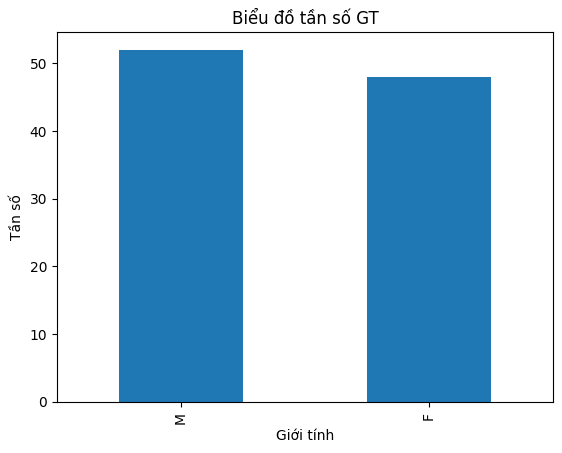

In [24]:
df['GT'].value_counts().plot(kind='bar')

plt.title('Biểu đồ tần số GT')
plt.xlabel('Giới tính')
plt.ylabel('Tần số')

plt.show()

2. Hãy trình bày dữ liệu lần lượt các biến: US_TBM1, US_TBM2 và US_TBM3


count    100.000000
mean       2.434480
std        0.391203
min        1.616000
25%        2.107000
50%        2.480000
75%        2.724000
max        3.232000
Name: US_TBM1, dtype: float64


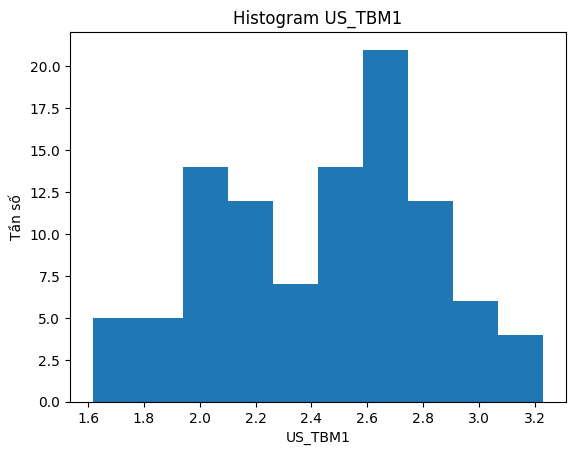

count    100.000000
mean       2.559600
std        0.377656
min        1.768000
25%        2.223000
50%        2.588000
75%        2.893000
max        3.416000
Name: US_TBM2, dtype: float64


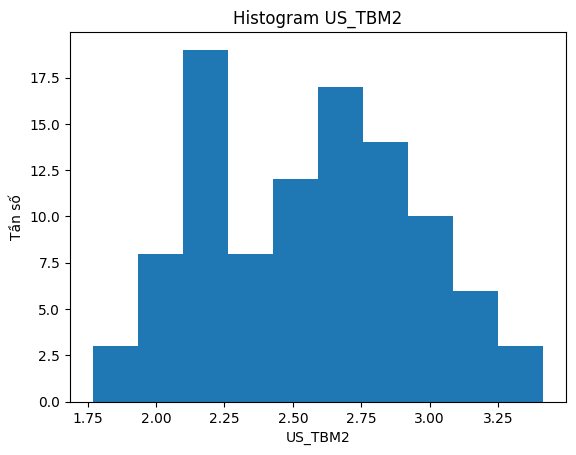

count    100.00000
mean       2.67176
std        0.29981
min        1.91600
25%        2.47300
50%        2.70600
75%        2.87400
max        3.31600
Name: US_TBM3, dtype: float64


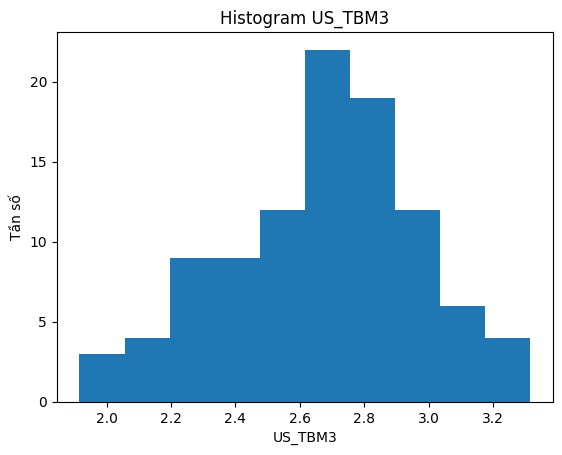

In [25]:
print(df['US_TBM1'].describe())
plt.hist(df['US_TBM1'])
plt.title('Histogram US_TBM1')
plt.xlabel('US_TBM1')
plt.ylabel('Tần số')
plt.show()

print(df['US_TBM2'].describe())
plt.hist(df['US_TBM2'])
plt.title('Histogram US_TBM2')
plt.xlabel('US_TBM2')
plt.ylabel('Tần số')
plt.show()

print(df['US_TBM3'].describe())
plt.hist(df['US_TBM3'])
plt.title('Histogram US_TBM3')
plt.xlabel('US_TBM3')
plt.ylabel('Tần số')
plt.show()

3. Hãy trình bày dữ liệu biến DT với các học sinh là nam


DT
0.0    50
1.0     1
6.0     1
Name: count, dtype: int64
DT
0.0    0.961538
1.0    0.019231
6.0    0.019231
Name: proportion, dtype: float64


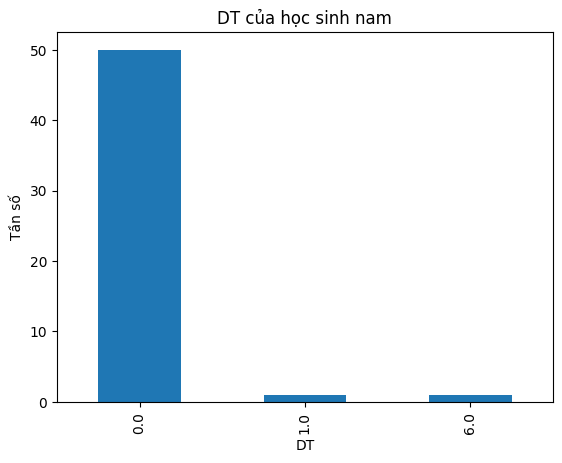

In [26]:
male_df = df[df['GT'] == 'M']

print(male_df['DT'].value_counts())

print(male_df['DT'].value_counts(normalize=True))

male_df['DT'].value_counts().plot(kind='bar')

plt.title('DT của học sinh nam')
plt.xlabel('DT')
plt.ylabel('Tần số')

plt.show()

4. Hãy trình bày dữ liệu biến KV với các học sinh là nam thuộc dân tộc Kinh, có điểm thỏa
mãn điều kiện (DH1 >= 5.0 và DH2 >= 4.0 và DH3 >= 4.0)


Series([], Name: count, dtype: int64)
Series([], Name: proportion, dtype: float64)


IndexError: index 0 is out of bounds for axis 0 with size 0

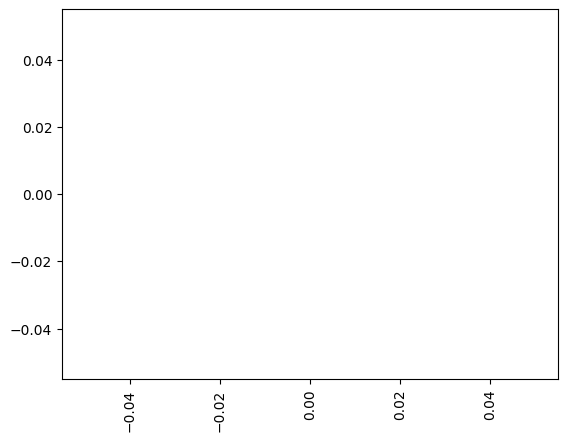

In [29]:
filtered_df = df[
    (df['GT'] == 'M') &
    (df['DT'] == 1) &
    (df['DH1'] >= 5.0) &
    (df['DH2'] >= 4.0) &
    (df['DH3'] >= 4.0)
]

print(filtered_df['KV'].value_counts())

print(filtered_df['KV'].value_counts(normalize=True))

filtered_df['KV'].value_counts().plot(kind='bar')

plt.title('KV của học sinh nam dân tộc Kinh')
plt.xlabel('KV')
plt.ylabel('Tần số')

plt.show()

5. Hãy trình bày dữ liệu lần lượt các biến DH1, DH2, DH3 lớn hơn bằng 5.0 và thuộc khu
vực 2NT

count    1.00
mean     6.75
std       NaN
min      6.75
25%      6.75
50%      6.75
75%      6.75
max      6.75
Name: DH1, dtype: float64


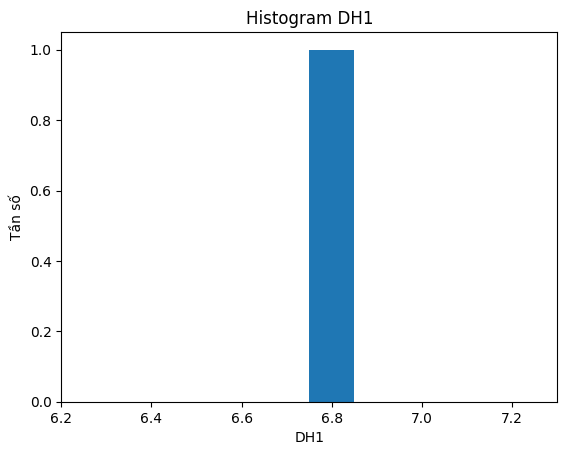

count    1.00
mean     5.25
std       NaN
min      5.25
25%      5.25
50%      5.25
75%      5.25
max      5.25
Name: DH2, dtype: float64


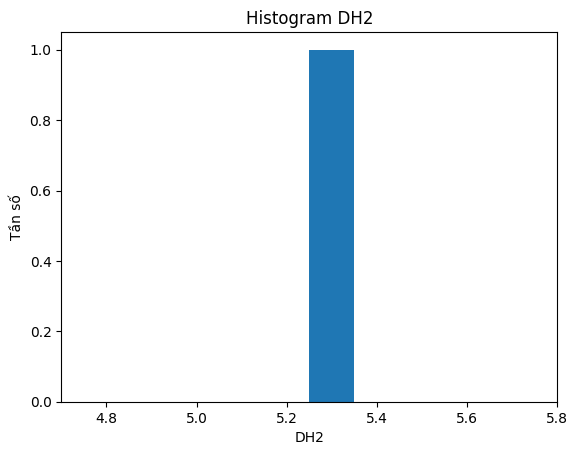

count    1.0
mean     5.0
std      NaN
min      5.0
25%      5.0
50%      5.0
75%      5.0
max      5.0
Name: DH3, dtype: float64


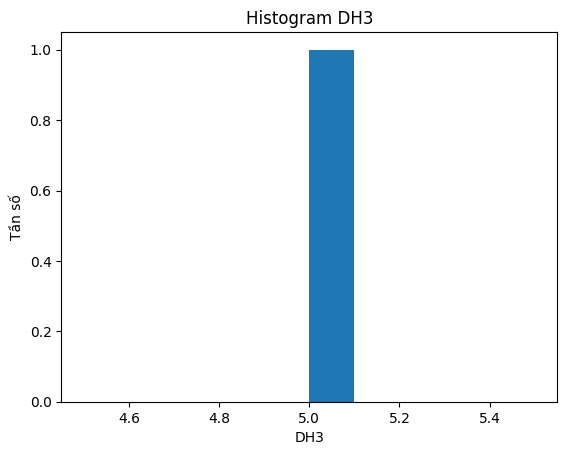

In [28]:
kv2nt_df = df[
    (df['KV'] == '2NT') &
    (df['DH1'] >= 5.0) &
    (df['DH2'] >= 5.0) &
    (df['DH3'] >= 5.0)
]
print(kv2nt_df['DH1'].describe())
plt.hist(kv2nt_df['DH1'])
plt.title('Histogram DH1')
plt.xlabel('DH1')
plt.ylabel('Tần số')
plt.show()


print(kv2nt_df['DH2'].describe())
plt.hist(kv2nt_df['DH2'])
plt.title('Histogram DH2')
plt.xlabel('DH2')
plt.ylabel('Tần số')
plt.show()


print(kv2nt_df['DH3'].describe())
plt.hist(kv2nt_df['DH3'])
plt.title('Histogram DH3')
plt.xlabel('DH3')
plt.ylabel('Tần số')
plt.show()

# Phần 3: Trực quan hóa dữ liệu theo nhóm phân loại

1. Trực quan dữ liệu học sinh nữ trên các nhóm XL1, XL2, XL3 dạng unstacked

    XL1  XL2   XL3
G     1    2   1.0
K    24   30  35.0
TB   18   15  12.0
Y     5    1   0.0


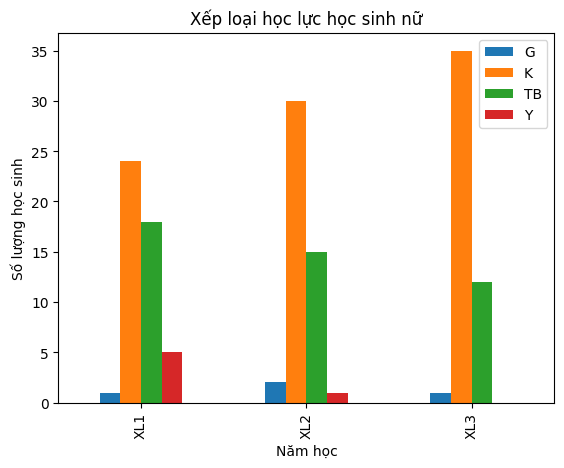

In [30]:
female_df = df[df['GT'] == 'F']
xl_counts = pd.DataFrame({
    'XL1': female_df['XL1'].value_counts(),
    'XL2': female_df['XL2'].value_counts(),
    'XL3': female_df['XL3'].value_counts()
}).fillna(0)

print(xl_counts)
xl_counts.T.plot(kind='bar')

plt.title('Xếp loại học lực học sinh nữ')
plt.xlabel('Năm học')
plt.ylabel('Số lượng học sinh')

plt.show()

2. Trực quan dữ liệu KQXT trên nhóm học sinh có khối thi A, A1, B thuộc khu vực 1, 2

KQXT  0.0  1.0
KT            
A      34    4
A1      2    0
B       8    0


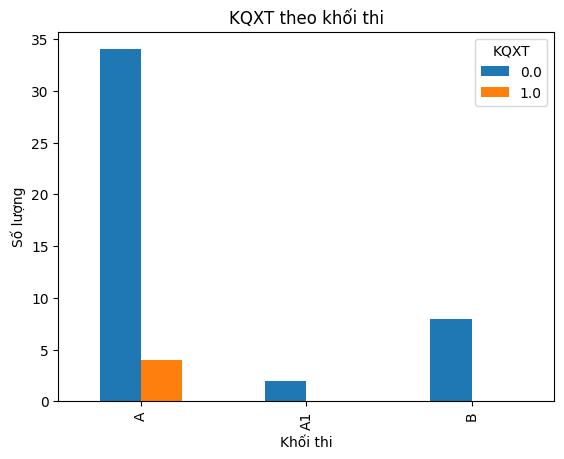

In [31]:
data = df[
    (df['KT'].isin(['A', 'A1', 'B'])) &
    (df['KV'].isin(['1', '2']))
]
table = pd.crosstab(
    data['KT'],
    data['KQXT']
)

print(table)
table.plot(kind='bar')

plt.title('KQXT theo khối thi')
plt.xlabel('Khối thi')
plt.ylabel('Số lượng')

plt.show()

3. Trực quan dữ liệu số lượng thí sinh từng khu vực dựa trên từng nhóm khối thi

KV   1  2  2NT
KT            
A   29  9   11
A1   2  0    4
B    8  0    1
C    8  2    4
D1  13  8    1


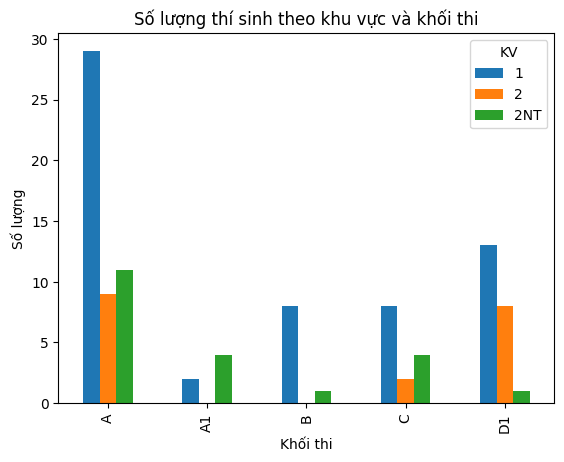

In [32]:
table = pd.crosstab(
    df['KT'],
    df['KV']
)

print(table)
table.plot(kind='bar')

plt.title('Số lượng thí sinh theo khu vực và khối thi')
plt.xlabel('Khối thi')
plt.ylabel('Số lượng')

plt.show()

4. Trực quan dữ liệu số lượng thí sinh đậu, rớt trên từng nhóm khối thi

In [ ]:
table = pd.crosstab(
    df['KT'],
    df['KQXT']
)

print(table)
table.plot(kind='bar')

plt.title('Đậu - Rớt theo khối thi')
plt.xlabel('Khối thi')
plt.ylabel('Số lượng')

plt.show()

5. Trực quan dữ liệu số lượng thí sinh đậu rớt trên từng nhóm khu vực.

In [ ]:
table = pd.crosstab(
    df['KV'],
    df['KQXT']
)

print(table)
table.plot(kind='bar')

plt.title('Đậu - Rớt theo khu vực')
plt.xlabel('Khu vực')
plt.ylabel('Số lượng')

plt.show()

6. Trực quan dữ liệu số lượng thí sinh đậu rớt dựa trên từng nhóm dân tộc

In [ ]:
table = pd.crosstab(
    df['DT'],
    df['KQXT']
)

print(table)
table.plot(kind='bar')

plt.title('Đậu - Rớt theo dân tộc')
plt.xlabel('Dân tộc')
plt.ylabel('Số lượng')

plt.show()

7. Trực quan dữ liệu số lượng thí sinh đậu rớt dựa trên từng nhóm giới tính.

KQXT  0.0  1.0
GT            
F      45    3
M      45    7


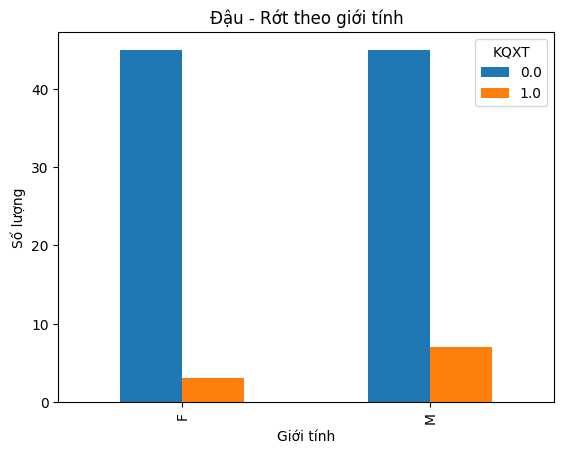

In [33]:
table = pd.crosstab(
    df['GT'],
    df['KQXT']
)

print(table)
table.plot(kind='bar')

plt.title('Đậu - Rớt theo giới tính')
plt.xlabel('Giới tính')
plt.ylabel('Số lượng')

plt.show()

# Phần 4: Trực quan hóa dữ liệu nâng cao

1. Vẽ biểu đồ đường Simple cho biến T1

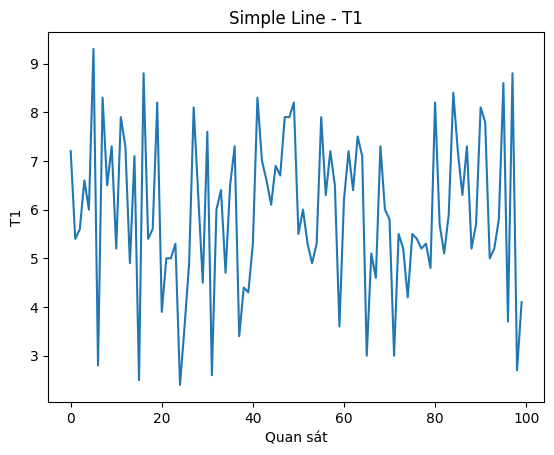

In [34]:
plt.plot(df['T1'])

plt.title('Simple Line - T1')
plt.xlabel('Quan sát')
plt.ylabel('T1')

plt.show()

2. Hãy tạo biến phân loại (phanlopt1) cho môn toán (T1) như sau:
a. Từ 0 đến dưới 5 = kém (ký hiệu “k”)  
b. Từ 5 đến dưới 7 = trung bình (ký hiệu “tb”)
c. Từ 7 đến dưới 8 = khá (ký hiệu “k”)
d. Từ 8 trở lên = giỏi (ký hiệu “g”)

In [36]:
def phanlop_t1(x):

    if x < 5:
        return 'kem'

    elif x < 7:
        return 'tb'

    elif x < 8:
        return 'kha'

    else:
        return 'gioi'

df['phanlopT1'] = df['T1'].apply(phanlop_t1)

3. Lập bảng tần số cho biến phanloait1

In [37]:
print(df['phanlopT1'].value_counts())

print(df['phanlopT1'].value_counts(normalize=True))

phanlopT1
tb      46
kem     23
kha     19
gioi    12
Name: count, dtype: int64
phanlopT1
tb      0.46
kem     0.23
kha     0.19
gioi    0.12
Name: proportion, dtype: float64


4. Vẽ biểu đồ đường Multiple Line cho biến T1 được phân loại bởi biến phanlopt1

In [ ]:
group = df.groupby('phanlopT1')['T1']

for name, values in group:
    plt.plot(values.values, label=name)

plt.title('Multiple Line T1')
plt.xlabel('Quan sát')
plt.ylabel('T1')

plt.legend()

plt.show()

5. Vẽ biểu đồ Drop-line cho biến T1 được phân loại bởi biến phanlopt1

In [ ]:
plt.stem(df.index, df['T1'])

plt.title('Drop Line T1')
plt.xlabel('Quan sát')
plt.ylabel('T1')

plt.show()

# Phần 5: Mô tả dữ liệu và khảo sát dạng phân phối

1. Hãy mô tả và khảo sát phân phối cho biến T1

count    100.000000
mean       5.946000
std        1.608338
min        2.400000
25%        5.000000
50%        5.850000
75%        7.200000
max        9.300000
Name: T1, dtype: float64
Skewness = -0.17824317486762223
Kurtosis = -0.48010360836580634


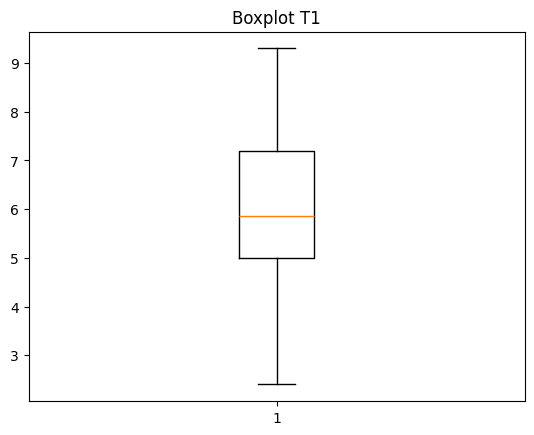

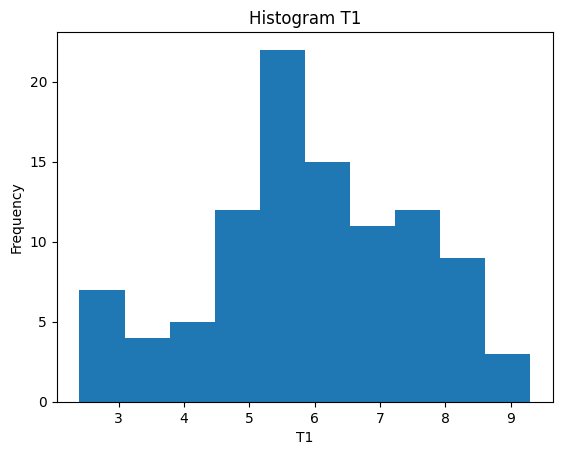

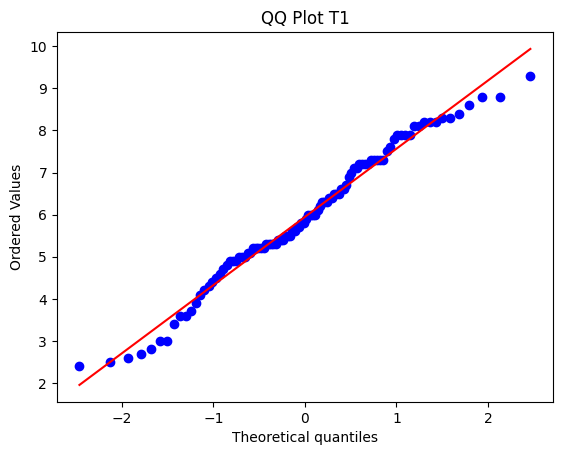

In [38]:
print(df['T1'].describe())
print("Skewness =", df['T1'].skew())
print("Kurtosis =", df['T1'].kurt())
plt.boxplot(df['T1'])

plt.title('Boxplot T1')

plt.show()
plt.hist(df['T1'], bins=10)

plt.title('Histogram T1')
plt.xlabel('T1')
plt.ylabel('Frequency')

plt.show()
from scipy import stats
import matplotlib.pyplot as plt
stats.probplot(df['T1'], dist="norm", plot=plt)

plt.title('QQ Plot T1')

plt.show()

2. Hãy mô tả và khảo sát phân phối cho biến T1 trên từng nhóm phân lớp (phanlopT1)

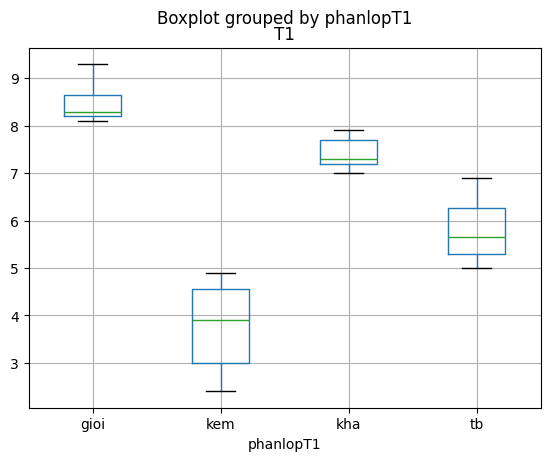

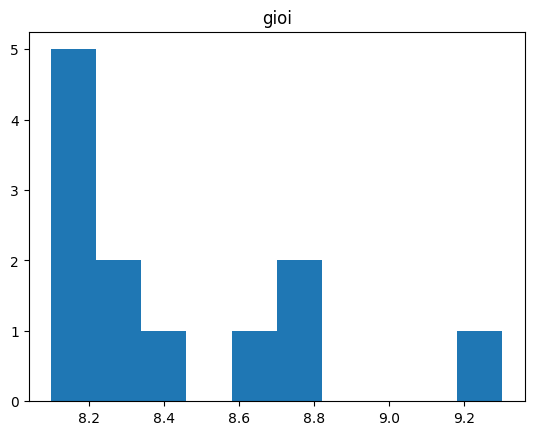

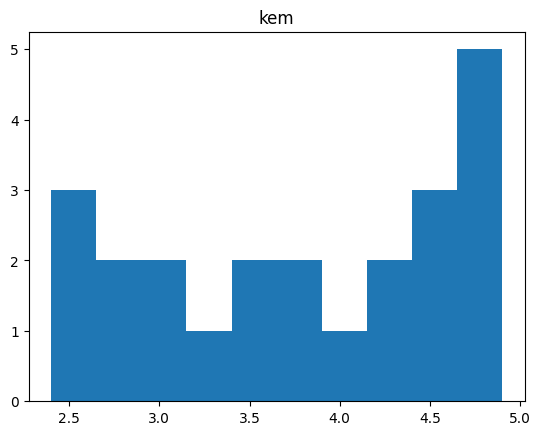

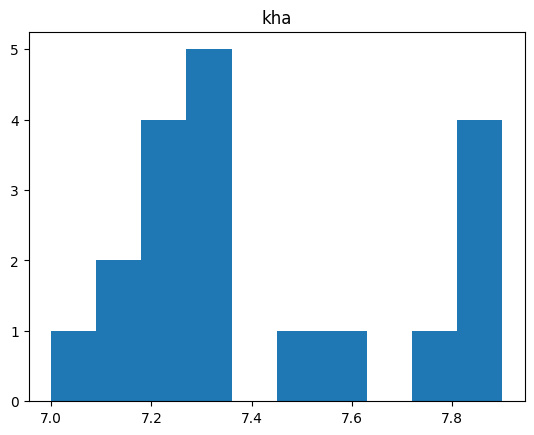

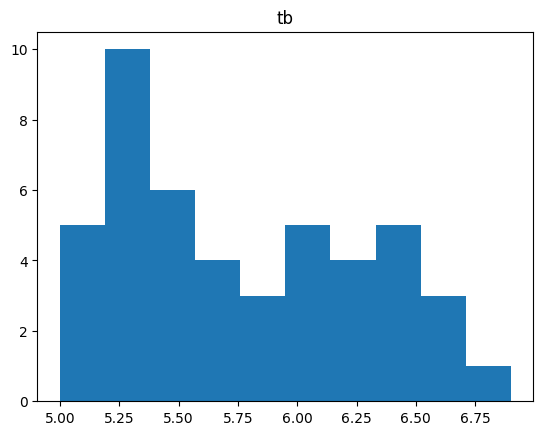

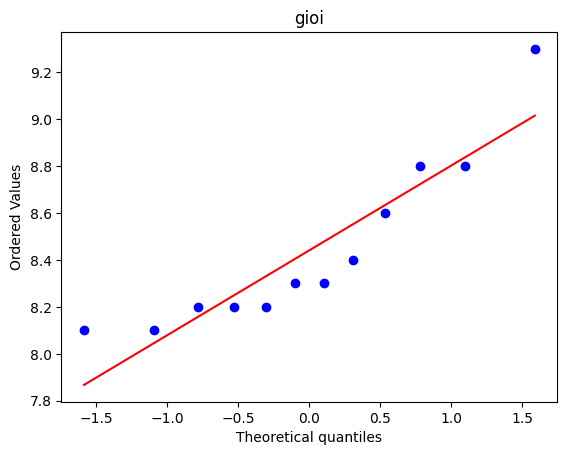

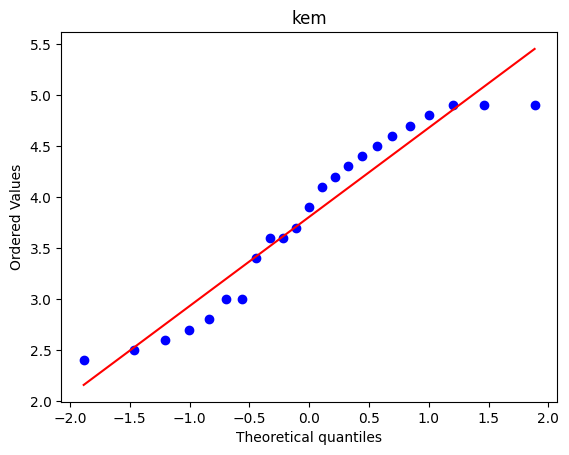

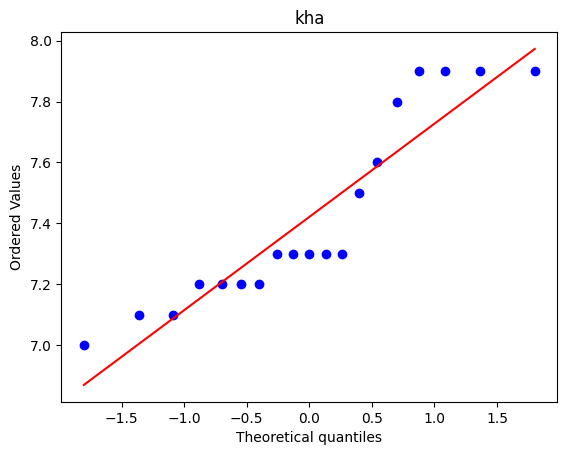

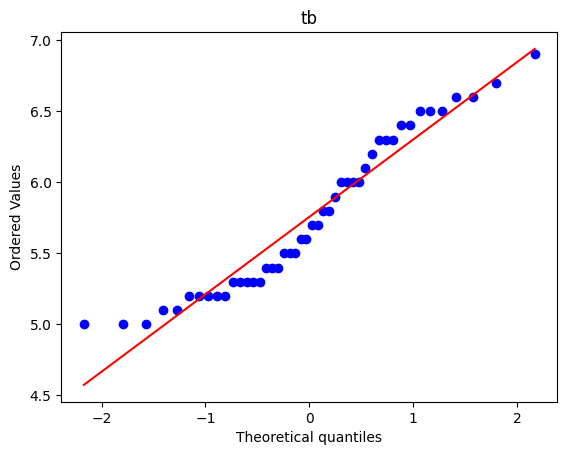

In [39]:
df.boxplot(column='T1', by='phanlopT1')

plt.show()
for name, group in df.groupby('phanlopT1'):

    plt.hist(group['T1'])

    plt.title(name)

    plt.show()
for name, group in df.groupby('phanlopT1'):

    stats.probplot(
        group['T1'],
        dist='norm',
        plot=plt
    )

    plt.title(name)

    plt.show()

3. Hãy khảo sát tương quan giữa biến DH1 theo biến T1

          DH1        T1
DH1  1.000000  0.049254
T1   0.049254  1.000000
          DH1        T1
DH1  2.028939  0.112838
T1   0.112838  2.586752


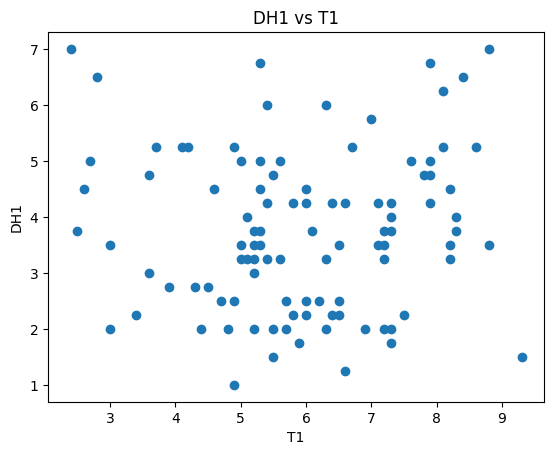

In [40]:
print(df[['DH1', 'T1']].corr())
print(df[['DH1', 'T1']].cov())
plt.scatter(df['T1'], df['DH1'])

plt.xlabel('T1')
plt.ylabel('DH1')

plt.title('DH1 vs T1')

plt.show()

4. Hãy khảo sát tương quan giữa biến DH1 theo biến T1 trên từng nhóm khu vực

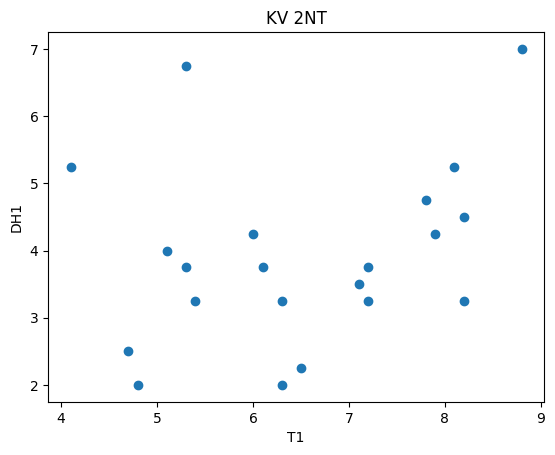

2NT           DH1        T1
DH1  1.000000  0.278469
T1   0.278469  1.000000


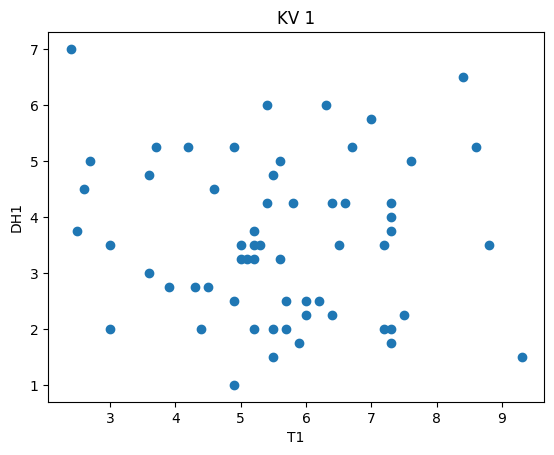

1           DH1        T1
DH1  1.000000 -0.079849
T1  -0.079849  1.000000


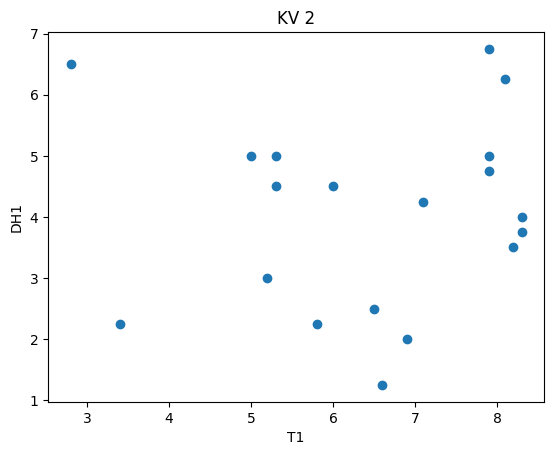

2           DH1        T1
DH1  1.000000  0.061743
T1   0.061743  1.000000


In [41]:
for kv in df['KV'].unique():

    temp = df[df['KV'] == kv]

    plt.scatter(
        temp['T1'],
        temp['DH1']
    )

    plt.title(f'KV {kv}')

    plt.xlabel('T1')
    plt.ylabel('DH1')

    plt.show()

    print(
        kv,
        temp[['DH1', 'T1']].corr()
    )

5. Hãy khảo sát tương quan giữa các biến DH1, DH2,  DH3

          DH1       DH2       DH3
DH1  1.000000  0.035154  0.018731
DH2  0.035154  1.000000 -0.091523
DH3  0.018731 -0.091523  1.000000
          DH1       DH2       DH3
DH1  2.028939  0.053081  0.027778
DH2  0.053081  1.123712 -0.101010
DH3  0.027778 -0.101010  1.083965


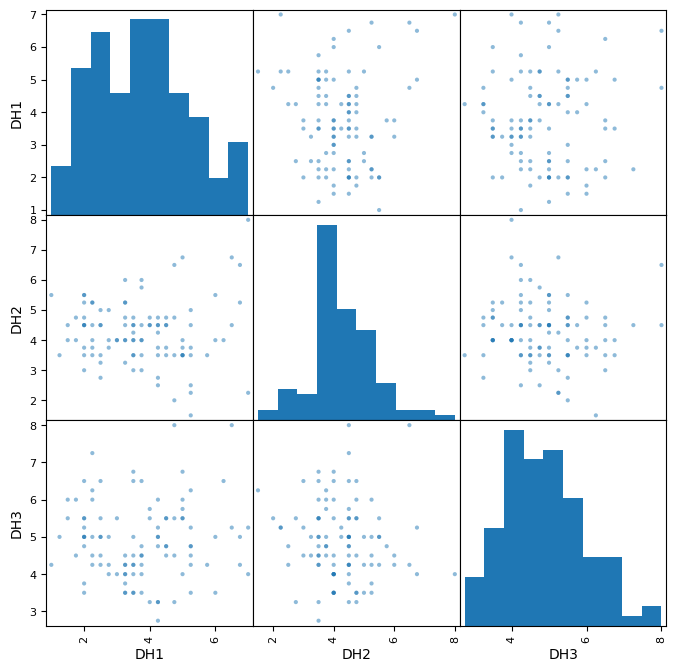

In [42]:
print(
    df[['DH1', 'DH2', 'DH3']].corr()
)
print(
    df[['DH1', 'DH2', 'DH3']].cov()
)
from pandas.plotting import scatter_matrix

scatter_matrix(
    df[['DH1', 'DH2', 'DH3']],
    figsize=(8,8)
)

plt.show()